In [ ]:
!pip install yfinance -q
import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt

df = yf.download("AAPL", start="2018-01-01", end="2026-09-30")
df.columns = df.columns.get_level_values(0)
df.head()

/tmp/ipykernel_4798/221474416.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2026-09-30")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232384,40.241728,39.531715,39.741918,102223600
2018-01-03,40.225376,40.767228,40.162319,40.295444,118071600
2018-01-04,40.412224,40.514989,40.190346,40.297780,89738400
2018-01-05,40.872318,40.958733,40.416885,40.507971,94640000
2018-01-08,40.720512,41.014792,40.622416,40.720512,82271200


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
count,2197.000000,2197.000000,2197.000000,2197.000000,2.197000e+03
mean,148.180699,149.686325,146.527378,148.031545,9.060671e+07
std,77.262480,77.981837,76.453824,77.166099,5.400208e+07
min,33.707916,34.544747,33.662874,34.132257,1.791060e+07
25%,70.863228,72.326882,69.665575,71.167130,5.201090e+07
50%,147.408844,148.625709,145.340033,146.823462,7.632210e+07
75%,199.883957,201.774808,197.555175,199.635155,1.115985e+08
max,341.070007,345.339996,338.750000,341.079987,4.265100e+08


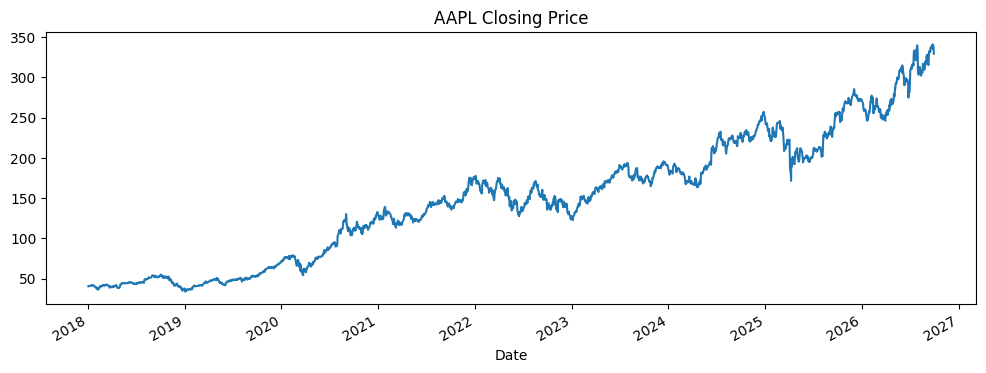

In [ ]:
df["Close"].plot(figsize=(12, 4), title="AAPL Closing Price")
plt.show()

In [ ]:
df["Target"] = df["Close"].shift(-1)   # next day's close
df = df.dropna()
X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Target"]

In [ ]:
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

MAE : 3.212468864859271
RMSE: 4.66130250159561
R2  : 0.9860178853278918


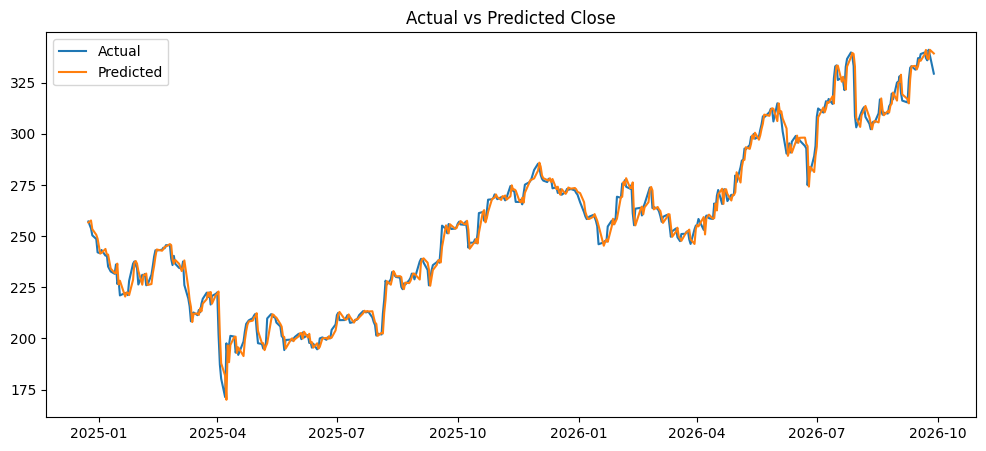

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, pred, label="Predicted")
plt.legend(); plt.title("Actual vs Predicted Close"); plt.show()